# ¿Que Habilidades son mas Requeridas paras los 3 puestos de trabajo con mas demanda?

## Proposito del Notebook
- Encontrar los 3 puestos de trabajos con mayor cantidad de ofertas.
- Encontrar el top 5 habilidades más solicitadas para esos puestos de trabajo. 
- Graficar todo en un subplot. 

## Cargar librerias y el archivo

In [1]:
import pandas as pd 
from rutas import ruta_archivo_limpio
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_parquet(ruta_archivo_limpio())
df_trabajar = df.copy()
df_trabajar

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'programming': ['py..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'analyst_tools': None, 'programming': ['pytho..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'analyst_tools': None, 'programming': ['bash'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'analyst_tools': None, 'programming': ['bash'..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel'], 'pr..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'analyst_tools': None, 'programming': ['pytho..."


## Proceso de Creación del Grafico

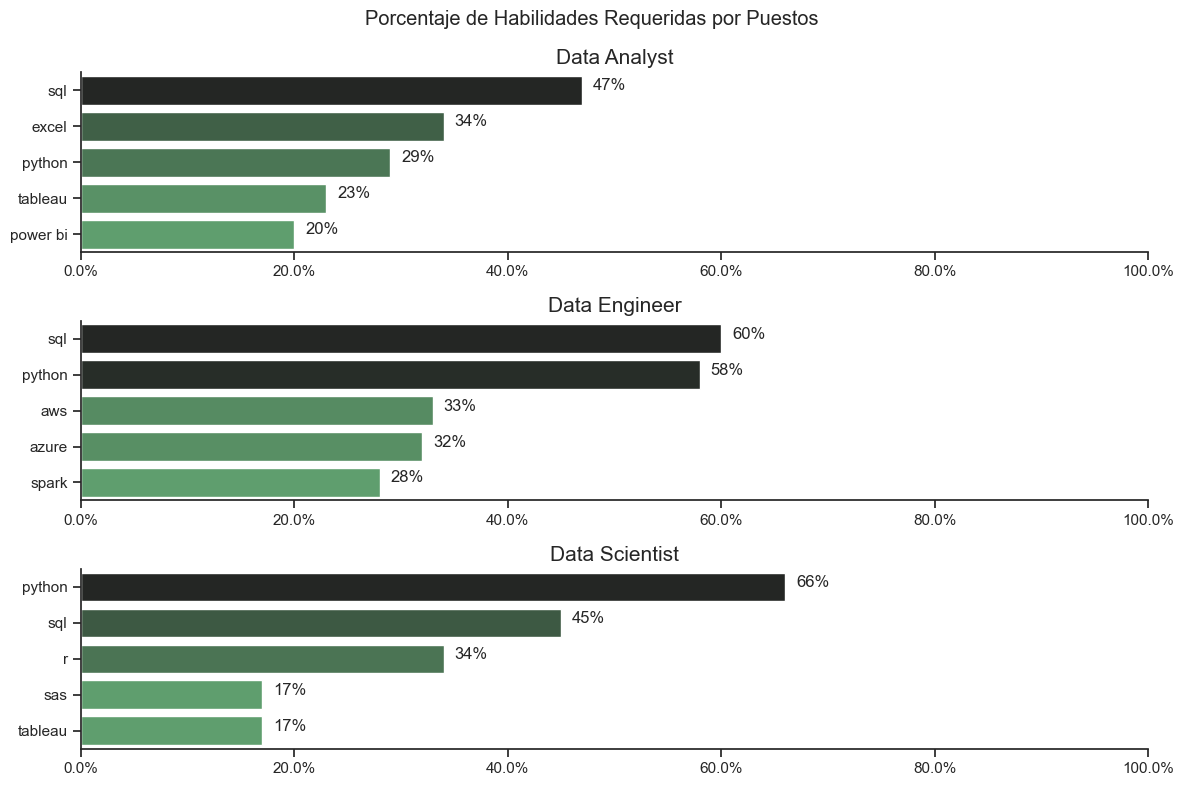

In [2]:
# Lista del nombre de los 3 roles con mayor cantidad de ofertas 
top_3_roles = df_trabajar.job_title_short.value_counts().head(3).index.to_list()

sns.set_theme(style='ticks')
fig, ax = plt.subplots(3,1,figsize= (12,8))

for i,rol in enumerate(top_3_roles): 
    # Cantidad total de ofertas de trabajo
    cantidad_filas = len(df_trabajar[df_trabajar.job_title_short == rol])
    # Filtra por rol y exapandimos 
    df_explode = df_trabajar[df_trabajar.job_title_short == rol].explode('job_skills')
    
    # TOP 5 habilidades más requeridas 
    df_grafico = df_explode[df_explode.job_title_short == rol].job_skills.value_counts().head(5).to_frame()
    
    # Calcula el porcentaje para cada uno 
    df_grafico['porcentaje'] = df_grafico['count'].apply(lambda valor: int(valor/cantidad_filas *100))
    
    # Grafico y Diseño
    sns.barplot(data=df_grafico,
                y= 'job_skills',
                x='porcentaje',
                ax=ax[i],
                hue='porcentaje',
                palette='dark:g_r',
                legend=False
    )
    
    ax[i].set_title(rol,loc='center',fontsize =15)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,100)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{x}%'))
    
    # Agrega los porcentajes al costado de las barras 
    for i2,indice in enumerate(df_grafico.index):
        ax[i].text(df_grafico.loc[indice,'porcentaje']+1,indice,f'{df_grafico.loc[indice,"porcentaje"]}%')
sns.despine()
fig.suptitle('Porcentaje de Habilidades Requeridas por Puestos')
fig.tight_layout()